# Phase 3: Scaling to MNIST
This notebook demonstrates how to scale the existing BP, PEPITA, and SoftHebb implementations to the MNIST dataset.

In [1]:
import os
import sys
import torch
import warnings
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import math
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath('..'))
from models.baseline_bp import BaselineMLP, train_bp_model
from models.pepita import PepitaMLP, train_pepita_model
from models.softhebb import SoftHebbMLP, train_softhebb_model
import torch.nn.functional as F
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import pandas as pd
from sklearn.decomposition import PCA
import numpy as np
import random


warnings.filterwarnings('ignore')

### 1. Load MNIST Dataset
We flatten the 28x28 images into 784-dimensional vectors so they can be fed into our MLPs.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: torch.flatten(x))
])

data_dir = '../data'
train_dataset = torchvision.datasets.MNIST(root=data_dir, train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root=data_dir, train=False, download=True, transform=transform)

batch_size = 128
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Train samples: 60000
Test samples: 10000


### 2. Initialize Models
For MNIST, the input dimension is 784, hidden dimension is scaled up (e.g., 512), and output dimension is 10.

In [3]:
input_dim = 784
hidden_dim = 512
output_dim = 10

bp_model = BaselineMLP(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim)
pep_model = PepitaMLP(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim)
sh_model = SoftHebbMLP(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim)

criterion = nn.CrossEntropyLoss()
epochs = 100

### 3. Train Backpropagation (Baseline)

In [4]:
print("--- Training Backpropagation ---")
optimizer_bp = optim.SGD(bp_model.parameters(), lr=0.01)
bp_train_loss, bp_train_acc, bp_test_loss, bp_test_acc = train_bp_model(
    bp_model, train_dataloader, test_dataloader, criterion, optimizer_bp, epochs=epochs
)

--- Training Backpropagation ---
Epoch 10/100 | Train Loss: 0.2895 | Train Acc: 91.74% | Test Loss: 0.2711 | Test Acc: 92.13%
Epoch 20/100 | Train Loss: 0.2092 | Train Acc: 94.09% | Test Loss: 0.2028 | Test Acc: 94.16%
Epoch 30/100 | Train Loss: 0.1587 | Train Acc: 95.47% | Test Loss: 0.1597 | Test Acc: 95.27%
Epoch 40/100 | Train Loss: 0.1242 | Train Acc: 96.53% | Test Loss: 0.1297 | Test Acc: 96.01%
Epoch 50/100 | Train Loss: 0.0991 | Train Acc: 97.20% | Test Loss: 0.1119 | Test Acc: 96.53%
Epoch 60/100 | Train Loss: 0.0811 | Train Acc: 97.76% | Test Loss: 0.0981 | Test Acc: 97.08%
Epoch 70/100 | Train Loss: 0.0674 | Train Acc: 98.16% | Test Loss: 0.0878 | Test Acc: 97.40%
Epoch 80/100 | Train Loss: 0.0567 | Train Acc: 98.47% | Test Loss: 0.0821 | Test Acc: 97.60%
Epoch 90/100 | Train Loss: 0.0482 | Train Acc: 98.75% | Test Loss: 0.0769 | Test Acc: 97.72%
Epoch 100/100 | Train Loss: 0.0413 | Train Acc: 98.97% | Test Loss: 0.0727 | Test Acc: 97.81%


### 4. Train PEPITA
PEPITA requires a random projection matrix `B` to map the output error back to the input dimension.

In [5]:
print("--- Training PEPITA ---")

sd = math.sqrt(1 / input_dim)
B = (torch.rand(input_dim, output_dim) * 2 * sd - sd) * 0.05

pep_train_loss, pep_train_acc, pep_test_loss, pep_test_acc = train_pepita_model(
    pep_model, train_dataloader, test_dataloader, B, criterion, optimizer_name='SGD', epochs=epochs, eta=0.01
)

--- Training PEPITA ---
Epoch 10/100 | Train Loss: 2.2378 | Train Acc: 71.28% | Test Loss: 2.2306 | Test Acc: 73.13%
Epoch 20/100 | Train Loss: 2.1066 | Train Acc: 77.90% | Test Loss: 2.0922 | Test Acc: 79.70%
Epoch 30/100 | Train Loss: 1.9729 | Train Acc: 81.08% | Test Loss: 1.9572 | Test Acc: 82.39%
Epoch 40/100 | Train Loss: 1.8839 | Train Acc: 82.97% | Test Loss: 1.8693 | Test Acc: 84.04%
Epoch 50/100 | Train Loss: 1.8266 | Train Acc: 84.19% | Test Loss: 1.8131 | Test Acc: 85.09%
Epoch 60/100 | Train Loss: 1.7875 | Train Acc: 85.07% | Test Loss: 1.7749 | Test Acc: 86.07%
Epoch 70/100 | Train Loss: 1.7592 | Train Acc: 85.80% | Test Loss: 1.7472 | Test Acc: 86.62%
Epoch 80/100 | Train Loss: 1.7377 | Train Acc: 86.44% | Test Loss: 1.7262 | Test Acc: 87.21%
Epoch 90/100 | Train Loss: 1.7207 | Train Acc: 86.92% | Test Loss: 1.7098 | Test Acc: 87.61%
Epoch 100/100 | Train Loss: 1.7069 | Train Acc: 87.39% | Test Loss: 1.6964 | Test Acc: 87.95%


### 5. Train SoftHebb

In [6]:
print("--- Training SoftHebb ---")
sh_train_loss, sh_train_acc, sh_test_loss, sh_test_acc = train_softhebb_model(
    sh_model, train_dataloader, test_dataloader, criterion, optimizer_name='SGD', epochs=epochs, eta=0.03
)

--- Training SoftHebb ---
Epoch 10/100 | Train Loss: 2.1151 | Train Acc: 77.42% | Test Loss: 2.1013 | Test Acc: 79.26%
Epoch 20/100 | Train Loss: 1.9879 | Train Acc: 80.71% | Test Loss: 1.9754 | Test Acc: 81.69%
Epoch 30/100 | Train Loss: 1.9162 | Train Acc: 82.33% | Test Loss: 1.9043 | Test Acc: 83.46%
Epoch 40/100 | Train Loss: 1.8706 | Train Acc: 83.25% | Test Loss: 1.8591 | Test Acc: 84.38%
Epoch 50/100 | Train Loss: 1.8389 | Train Acc: 84.06% | Test Loss: 1.8269 | Test Acc: 84.83%
Epoch 60/100 | Train Loss: 1.8152 | Train Acc: 84.60% | Test Loss: 1.8035 | Test Acc: 85.38%
Epoch 70/100 | Train Loss: 1.7966 | Train Acc: 85.04% | Test Loss: 1.7844 | Test Acc: 85.51%
Epoch 80/100 | Train Loss: 1.7817 | Train Acc: 85.41% | Test Loss: 1.7708 | Test Acc: 86.05%
Epoch 90/100 | Train Loss: 1.7692 | Train Acc: 85.72% | Test Loss: 1.7581 | Test Acc: 86.34%
Epoch 100/100 | Train Loss: 1.7588 | Train Acc: 86.00% | Test Loss: 1.7475 | Test Acc: 86.66%


### 6. Plot Results

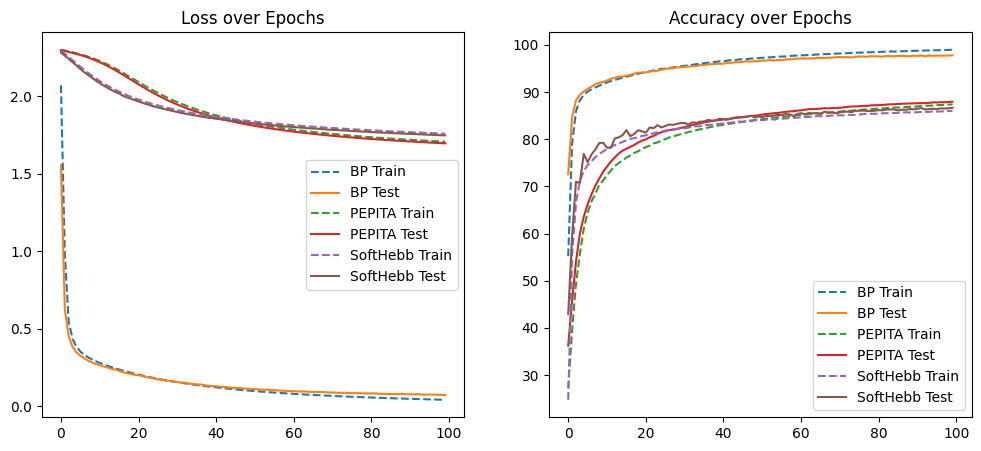

In [7]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(bp_train_loss, label='BP Train', linestyle='--')
plt.plot(bp_test_loss, label='BP Test')
plt.plot(pep_train_loss, label='PEPITA Train', linestyle='--')
plt.plot(pep_test_loss, label='PEPITA Test')
plt.plot(sh_train_loss, label='SoftHebb Train', linestyle='--')
plt.plot(sh_test_loss, label='SoftHebb Test')
plt.title('Loss over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(bp_train_acc, label='BP Train', linestyle='--')
plt.plot(bp_test_acc, label='BP Test')
plt.plot(pep_train_acc, label='PEPITA Train', linestyle='--')
plt.plot(pep_test_acc, label='PEPITA Test')
plt.plot(sh_train_acc, label='SoftHebb Train', linestyle='--')
plt.plot(sh_test_acc, label='SoftHebb Test')
plt.title('Accuracy over Epochs')
plt.legend()
os.makedirs('renders', exist_ok=True)
plt.savefig('renders/acc mnist.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

### 7. Extract Representations
We use forward hooks to extract the hidden representations of the test set for all models.

In [8]:
def get_representations(model, dataloader, device='cpu'):
    model.eval()
    reps_fc1 = []
    reps_fc2 = []
    labels_list = []
    
    act = {}
    def hook_fc1(m, i, o):
        act['fc1'] = o.detach()
    def hook_fc2(m, i, o):
        act['fc2'] = o.detach()
        
    h1 = model.fc1.register_forward_hook(hook_fc1)
    h2 = model.fc2.register_forward_hook(hook_fc2)
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            _ = model(inputs)
            
            reps_fc1.append(F.relu(act['fc1']).cpu())
            reps_fc2.append(F.relu(act['fc2']).cpu())
            labels_list.append(labels)
            
    h1.remove()
    h2.remove()
    return torch.cat(reps_fc1), torch.cat(reps_fc2), torch.cat(labels_list)

train_eval_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
print("Extracting training representations...")

bp_fc1_train, bp_fc2_train, train_labels = get_representations(bp_model, train_eval_dataloader)
pep_fc1_train, pep_fc2_train, _ = get_representations(pep_model, train_eval_dataloader)
sh_fc1_train, sh_fc2_train, _ = get_representations(sh_model, train_eval_dataloader)

print("Extracting test representations...")
bp_fc1_test, bp_fc2_test, test_labels = get_representations(bp_model, test_dataloader)
pep_fc1_test, pep_fc2_test, _ = get_representations(pep_model, test_dataloader)
sh_fc1_test, sh_fc2_test, _ = get_representations(sh_model, test_dataloader)

bp_fc1_reps = bp_fc1_test
pep_fc1_reps = pep_fc1_test
sh_fc1_reps = sh_fc1_test

print(f"BP Train FC1 shape: {bp_fc1_train.shape}, FC2 shape: {bp_fc2_train.shape}")
print(f"PEPITA Train FC1 shape: {pep_fc1_train.shape}, FC2 shape: {pep_fc2_train.shape}")
print(f"SoftHebb Train FC1 shape: {sh_fc1_train.shape}, FC2 shape: {sh_fc2_train.shape}")
print(f"BP Test FC1 shape: {bp_fc1_test.shape}, FC2 shape: {bp_fc2_test.shape}")

Extracting training representations...
Extracting test representations...
BP Train FC1 shape: torch.Size([60000, 512]), FC2 shape: torch.Size([60000, 512])
PEPITA Train FC1 shape: torch.Size([60000, 512]), FC2 shape: torch.Size([60000, 512])
SoftHebb Train FC1 shape: torch.Size([60000, 512]), FC2 shape: torch.Size([60000, 512])
BP Test FC1 shape: torch.Size([10000, 512]), FC2 shape: torch.Size([10000, 512])


### 7.5 Linear Probing
**What it is:** Linear probing involves training a simple, non-deep logistic regression classifier directly on the frozen features of an intermediate layer. 
**Why it matters:** It tells us how linearly separable the data has become at that specific depth. If Layer 1 yields high probing accuracy, it means the network has already successfully transformed the complex manifold into an easily solvable linear space early on.

,Method,Layer,Train Acc,Test Acc
0,BP,FC1,0.999633,0.9775
1,BP,FC2,0.998500,0.9797
2,PEP,FC1,0.971650,0.9464
3,PEP,FC2,0.969933,0.9488
4,SH,FC1,0.968983,0.9448
5,SH,FC2,0.952983,0.9294


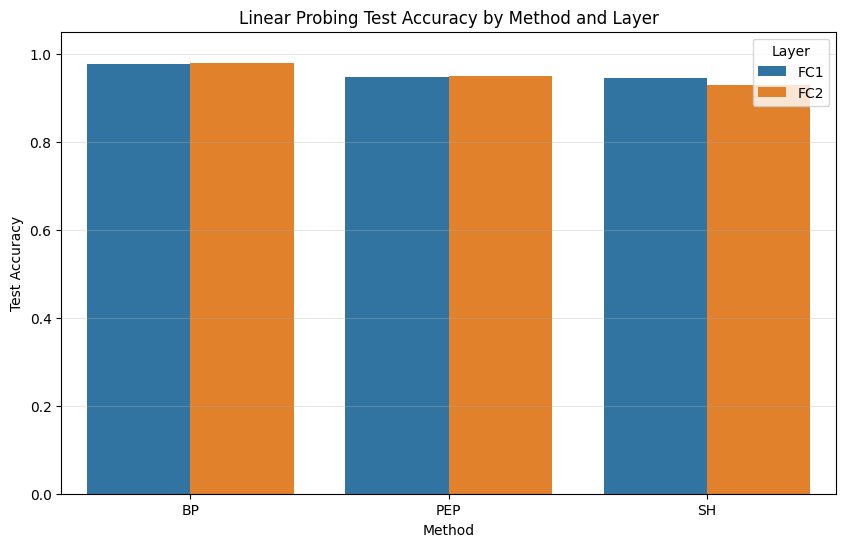

In [9]:
train_activations = {
    'bp_fc1': bp_fc1_train.numpy(),
    'bp_fc2': bp_fc2_train.numpy(),
    'pep_fc1': pep_fc1_train.numpy(),
    'pep_fc2': pep_fc2_train.numpy(),
    'sh_fc1': sh_fc1_train.numpy(),
    'sh_fc2': sh_fc2_train.numpy()
}

test_activations = {
    'bp_fc1': bp_fc1_test.numpy(),
    'bp_fc2': bp_fc2_test.numpy(),
    'pep_fc1': pep_fc1_test.numpy(),
    'pep_fc2': pep_fc2_test.numpy(),
    'sh_fc1': sh_fc1_test.numpy(),
    'sh_fc2': sh_fc2_test.numpy()
}

def perform_linear_probing(layer_name):
    X_tr = train_activations[layer_name]
    y_tr = train_labels.numpy()
    X_te = test_activations[layer_name]
    y_te = test_labels.numpy()
    
    
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te)
    
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_tr_scaled, y_tr)
    
    train_acc = accuracy_score(y_tr, clf.predict(X_tr_scaled))
    test_acc = accuracy_score(y_te, clf.predict(X_te_scaled))
    return train_acc, test_acc

results = []
layers = ['bp_fc1', 'bp_fc2', 'pep_fc1', 'pep_fc2', 'sh_fc1', 'sh_fc2']

for layer in layers:
    tr_acc, te_acc = perform_linear_probing(layer)
    method, l_name = layer.split('_')
    results.append({
        'Method': method.upper(),
        'Layer': l_name.upper(),
        'Train Acc': tr_acc,
        'Test Acc': te_acc
    })

df_probing = pd.DataFrame(results)
display(df_probing)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_probing, x='Method', y='Test Acc', hue='Layer')
plt.title('Linear Probing Test Accuracy by Method and Layer')
plt.ylim(0, 1.05)
plt.ylabel('Test Accuracy')
plt.grid(axis='y', alpha=0.3)
plt.show()

### 8. PCA Visualization
We project the 512-dimensional hidden representations down to 2 dimensions using PCA.

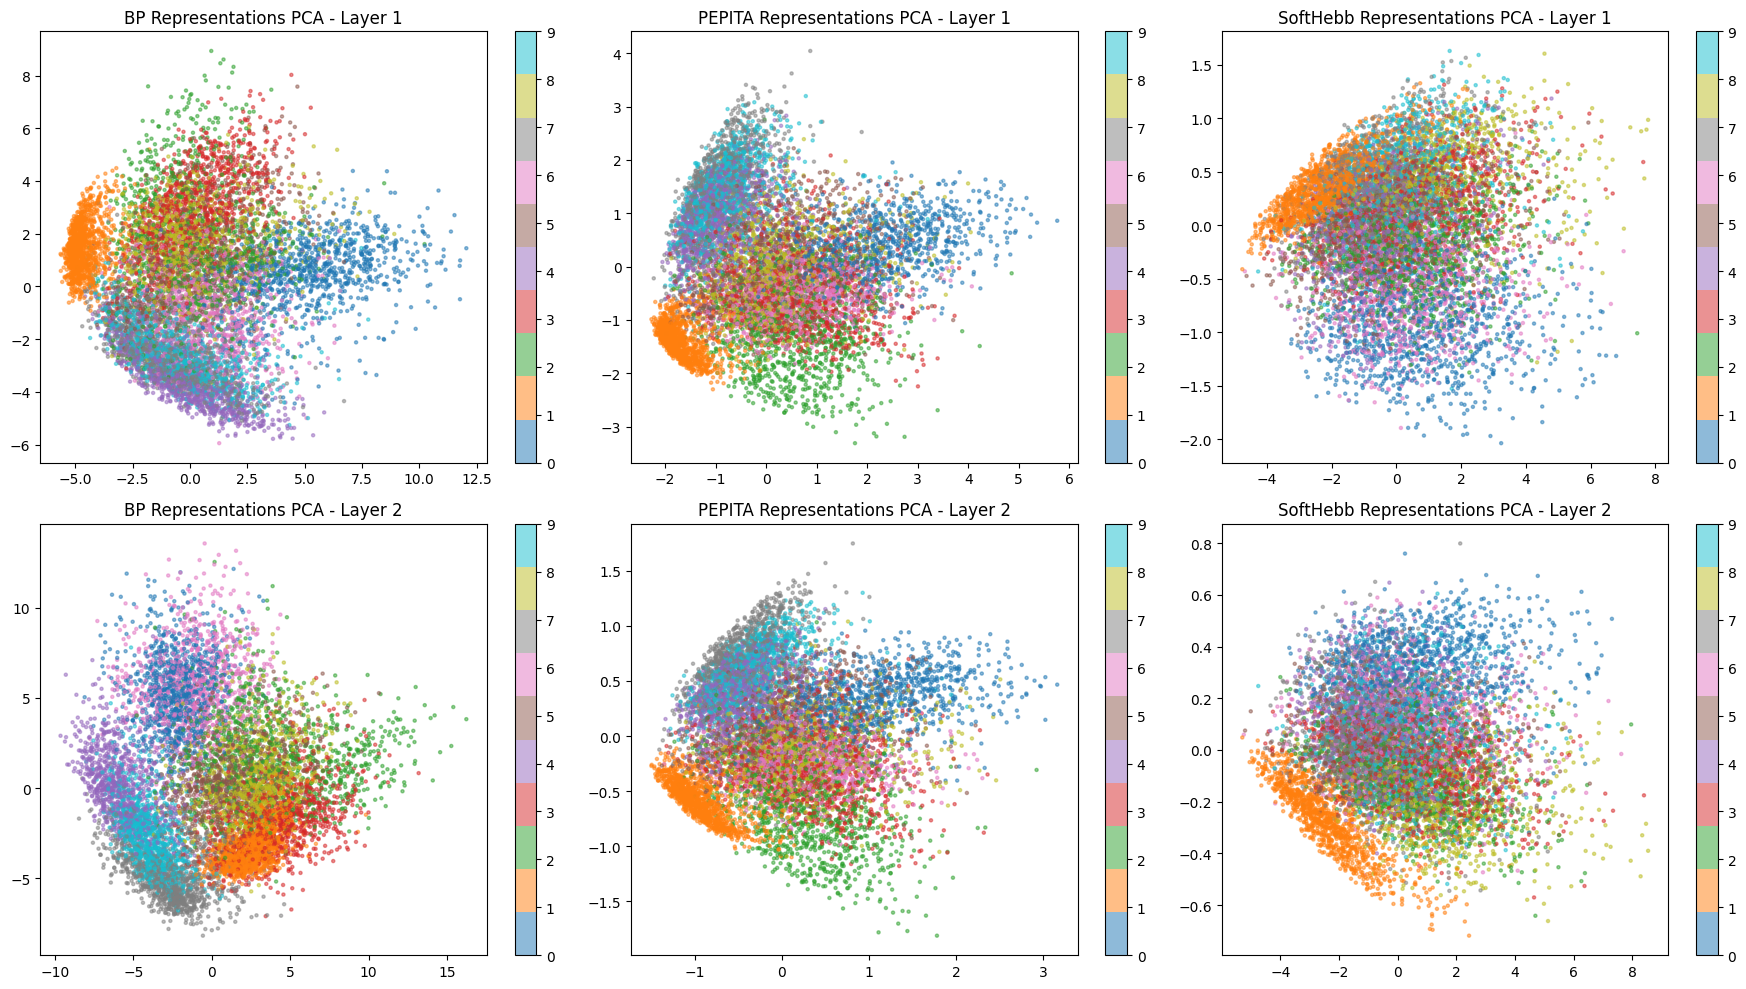

In [10]:
def plot_pca(reps, labels, title):
    pca = PCA(n_components=2)
    reps_pca = pca.fit_transform(reps.numpy())
    
    plt.scatter(reps_pca[:, 0], reps_pca[:, 1], c=labels.numpy(), cmap='tab10', alpha=0.5, s=5, rasterized=True)
    plt.colorbar()
    plt.title(title)

plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plot_pca(bp_fc1_test, test_labels, 'BP Representations PCA - Layer 1')

plt.subplot(2, 3, 2)
plot_pca(pep_fc1_test, test_labels, 'PEPITA Representations PCA - Layer 1')

plt.subplot(2, 3, 3)
plot_pca(sh_fc1_test, test_labels, 'SoftHebb Representations PCA - Layer 1')

plt.subplot(2, 3, 4)
plot_pca(bp_fc2_test, test_labels, 'BP Representations PCA - Layer 2')

plt.subplot(2, 3, 5)
plot_pca(pep_fc2_test, test_labels, 'PEPITA Representations PCA - Layer 2')

plt.subplot(2, 3, 6)
plot_pca(sh_fc2_test, test_labels, 'SoftHebb Representations PCA - Layer 2')

plt.tight_layout()
os.makedirs('renders', exist_ok=True)
plt.savefig('renders/pca.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

### 9. CKA (Centered Kernel Alignment)
We compute the Linear CKA between the representations of the different models to see how similarly they process the data.

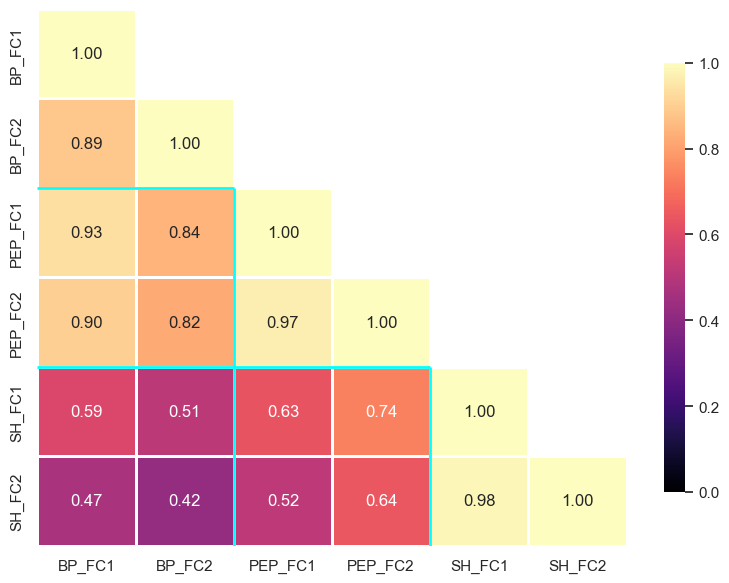

In [11]:
def linear_cka(X, Y):
    X_c = X - X.mean(axis=0)
    Y_c = Y - Y.mean(axis=0)
    XX = X_c @ X_c.T
    YY = Y_c @ Y_c.T
    return np.sum(XX * YY) / (np.linalg.norm(XX, 'fro') * np.linalg.norm(YY, 'fro'))

test_activations = {
    'bp_fc1': bp_fc1_test.numpy(),
    'bp_fc2': bp_fc2_test.numpy(),
    'pep_fc1': pep_fc1_test.numpy(),
    'pep_fc2': pep_fc2_test.numpy(),
    'sh_fc1': sh_fc1_test.numpy(),
    'sh_fc2': sh_fc2_test.numpy()
}

layers = ['bp_fc1', 'bp_fc2', 'pep_fc1', 'pep_fc2', 'sh_fc1', 'sh_fc2']
n_layers = len(layers)
cka_matrix = np.zeros((n_layers, n_layers))

for i, ki in enumerate(layers):
    for j, kj in enumerate(layers):
        cka_matrix[i, j] = linear_cka(test_activations[ki], test_activations[kj])

mask = np.triu(np.ones_like(cka_matrix, dtype=bool), k=1)

plt.figure(figsize=(8, 6))
sns.set_theme(style="white") # Professional paper style

ax = sns.heatmap(
    cka_matrix, mask=mask, annot=True, fmt='.2f', 
    xticklabels=[l.upper() for l in layers], 
    yticklabels=[l.upper() for l in layers], 
    cmap='magma', vmin=0, vmax=1, linewidths=1, linecolor='white',
    cbar_kws={"shrink": .8}
)

# Cyan dividers perfectly constrained to the lower triangle
ax.hlines([2, 4], xmin=0, xmax=[2, 4], colors='cyan', linewidths=2)
ax.vlines([2, 4], ymin=[2, 4], ymax=n_layers, colors='cyan', linewidths=2)

# plt.title('Cross-Model and Cross-Layer Representational Similarity (CKA)', fontsize=16, pad=20)
plt.tight_layout()
os.makedirs('renders', exist_ok=True)
plt.savefig('renders/cka.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

### 10. Gradient-Based Saliency Map Visualization
We compute saliency maps to visualize which input pixels each model relies on for its predictions. For a given input image, we backpropagate the total activation of a hidden layer back to the input and take the absolute gradient as the saliency.
- **L1 Saliency**: Gradients of the `fc1` layer activations with respect to the input, showing which pixels influence the first hidden layer.
- **L2 Saliency**: Gradients of the `fc2` layer activations with respect to the input, showing which pixels influence the second hidden layer.

We compare saliency maps across BP, PEPITA, and SoftHebb for a sample digit, alongside each model's output predictions.

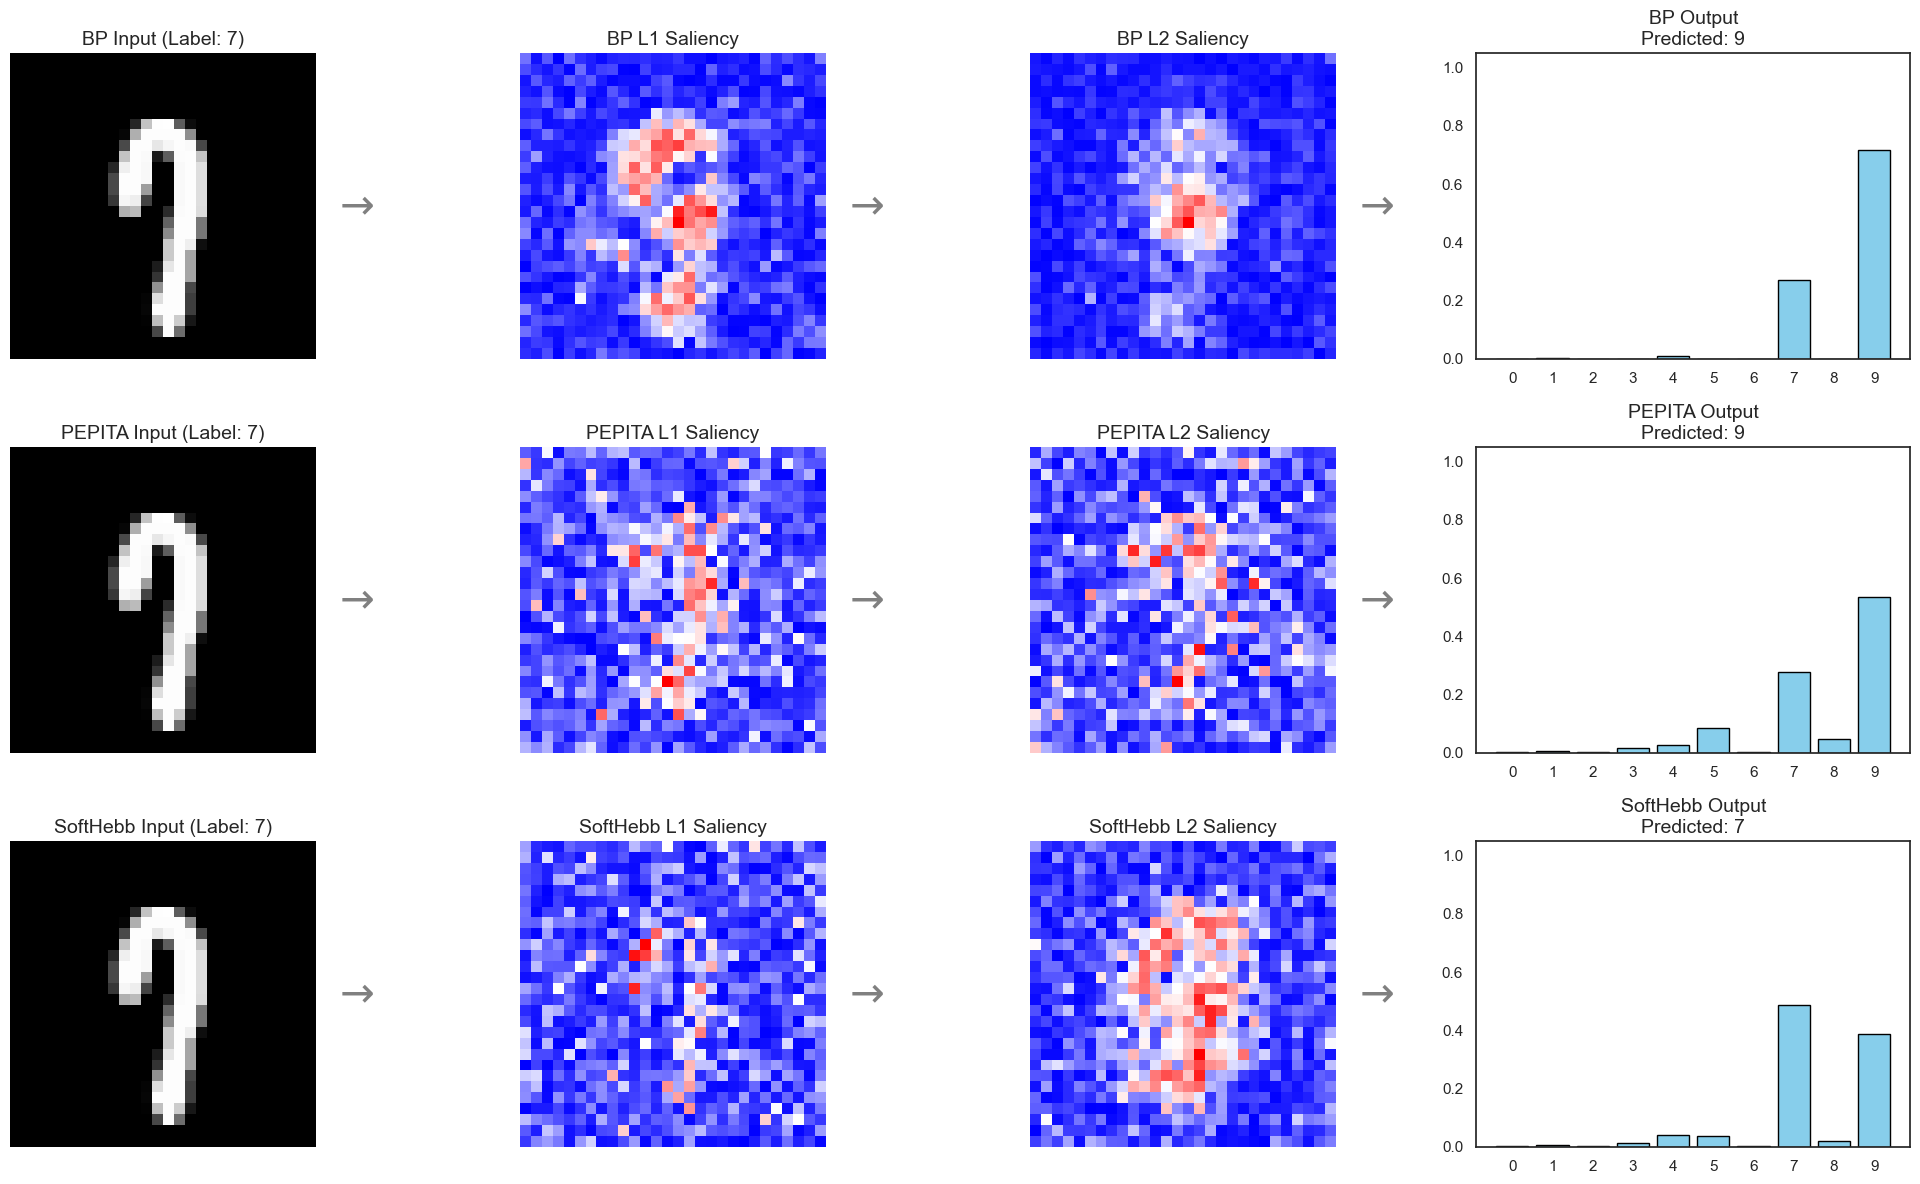

In [12]:
def compute_layer_saliency(model, input_image, layer_idx):
    model.eval()
    
    input_image = input_image.clone().detach().requires_grad_(True)
    
    x = model.fc1(input_image)
    x = nn.functional.relu(x)
    
    if layer_idx == 2:
        x = model.fc2(x)
        x = nn.functional.relu(x) 
        
    layer_activation = x.sum()
    layer_activation.backward()
    
    saliency = input_image.grad.abs().detach().cpu().numpy().reshape(28, 28)
    return saliency

target_label = 7

matching_indices = (test_dataset.targets == target_label).nonzero(as_tuple=True)[0]
random_idx = random.choice(matching_indices).item()
sample_img_raw, true_label = test_dataset[random_idx]
sample_img = sample_img_raw.unsqueeze(0)

original_img = sample_img.cpu().numpy().reshape(28, 28)
classes = np.arange(10)

models = [
    ('BP', bp_model),
    ('PEPITA', pep_model),
    ('SoftHebb', sh_model)
]

fig, axes = plt.subplots(3, 4, figsize=(20, 12))

for row_idx, (model_name, model) in enumerate(models):
    saliency_l1 = compute_layer_saliency(model, sample_img, layer_idx=1)
    saliency_l2 = compute_layer_saliency(model, sample_img, layer_idx=2)
    
    with torch.no_grad():
        model.eval()

        raw_output = model(sample_img)
        if isinstance(model, (PepitaMLP, SoftHebbMLP)):
            output_probs = raw_output[0].cpu().numpy()
        else:
            output_probs = F.softmax(raw_output, dim=1)[0].cpu().numpy()
        
    axes[row_idx, 0].imshow(original_img, cmap='gray')
    axes[row_idx, 0].set_title(f"{model_name} Input (Label: {true_label})", fontsize=14)
    axes[row_idx, 0].axis('off')
    
    axes[row_idx, 1].imshow(saliency_l1, cmap='bwr')
    axes[row_idx, 1].set_title(f"{model_name} L1 Saliency", fontsize=14)
    axes[row_idx, 1].axis('off')
    
    axes[row_idx, 2].imshow(saliency_l2, cmap='bwr')
    axes[row_idx, 2].set_title(f"{model_name} L2 Saliency", fontsize=14)
    axes[row_idx, 2].axis('off')
    
    axes[row_idx, 3].bar(classes, output_probs, color='skyblue', edgecolor='black')
    axes[row_idx, 3].set_xticks(classes)
    axes[row_idx, 3].set_title(f"{model_name} Output\nPredicted: {np.argmax(output_probs)}", fontsize=14)
    axes[row_idx, 3].set_ylim(0, 1.05)
    
    for col_idx in range(3):
        axes[row_idx, col_idx].annotate('$\\rightarrow$', xy=(1.05, 0.5), xycoords='axes fraction', 
                                        fontsize=30, va='center', ha='left', color='gray')

plt.tight_layout()
os.makedirs('renders', exist_ok=True)
plt.savefig('renders/saliency.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()